# DL059 自监督与对比学习

先写增强的预测，再从头运行。所有数据原创合成，CPU离线。Notebook重新训练所有配置，不覆盖参考outputs。

In [1]:
from pathlib import Path
import sys,json,math
import numpy as np
import torch
ROOT=next((p.resolve() for p in [Path.cwd(),Path.cwd()/"units"/"059"] if p.name=="059" and (p/"experiment.py").exists()),None)
if ROOT is None: raise RuntimeError("请从059或课程根目录启动")
sys.path.insert(0,str(ROOT))
from experiment import *
print("Python",sys.version.split()[0],"torch",torch.__version__,"NumPy",np.__version__)


Python 3.12.14 torch 2.14.1+cpu NumPy 2.3.5


## 1 原始信号与独立干扰
各划分独立，预训练不读验证或测试输入。

In [2]:
d=make_data()
for s in ["train","validation","test"]:print(s,d["x_"+s].shape,np.unique(d["y_"+s],return_counts=True))


train (768, 8) (array([0, 1, 2, 3]), array([192, 192, 192, 192]))
validation (192, 8) (array([0, 1, 2, 3]), array([48, 48, 48, 48]))
test (384, 8) (array([0, 1, 2, 3]), array([96, 96, 96, 96]))


## 2 四视图手算
τ=1预期0.551445；三个常量嵌入预期log5。

In [3]:
x=torch.eye(2,requires_grad=True)
loss=info_nce(x,x,1.);loss.backward()
print("loss",loss.item(),"hand",math.log(math.e+2)-1,"gradient",x.grad)
print("collapsed B3",info_nce(torch.ones(3,2),torch.ones(3,2)).item(),math.log(5))


loss 0.5514446496963501 hand 0.5514447139320509 gradient tensor([[0.0000, 0.4239],
        [0.4239, 0.0000]])
collapsed B3 1.6094379425048828 1.6094379124341003


## 3 视图究竟改变了谁
观察前后四维变化，说明正对索引不等于语义正确。

In [4]:
x=torch.from_numpy(d["x_train"][:128])
for kind in ["good","bad"]:
 v=augment(x,kind,torch.Generator().manual_seed(4))
 print(kind,"signal MSE",(v[:,:4]-x[:,:4]).square().mean().item(),"nuisance MSE",(v[:,4:]-x[:,4:]).square().mean().item())


good signal MSE 0.0016583282267674804 nuisance MSE 8.229408264160156
bad signal MSE 0.9703848361968994 nuisance MSE 0.0016541352961212397


## 4 验证参考证据
测试必须找到12组权重和探测器，并逐样本重放。

In [5]:
from test_experiment import main as check
check(ROOT/"outputs")


test_guards_and_augmentation (test_experiment.Checks.test_guards_and_augmentation) ... 

ok


test_nce_hand_and_masks (test_experiment.Checks.test_nce_hand_and_masks) ... 

ok


test_probe_and_replay (test_experiment.Checks.test_probe_and_replay) ... 

ok


----------------------------------------------------------------------
Ran 3 tests in 0.036s

OK


## 5 真正完整重训
九次350步训练与三个随机基准。写入独立notebook_replay。

In [6]:
result=run(ROOT/"notebook_replay")
check(ROOT/"notebook_replay")
print(json.dumps(result["protocol"],ensure_ascii=False,indent=2))


test_guards_and_augmentation (test_experiment.Checks.test_guards_and_augmentation) ... 

ok


test_nce_hand_and_masks (test_experiment.Checks.test_nce_hand_and_masks) ... 

ok


test_probe_and_replay (test_experiment.Checks.test_probe_and_replay) ... 

ok


----------------------------------------------------------------------
Ran 3 tests in 0.031s

OK


{
  "unit": "059",
  "steps": 350,
  "batch_originals": 64,
  "anchors": 128,
  "temperature": 0.2,
  "probe_labeled_prefix": 128,
  "probe_ridge": 1.0,
  "probe_features": 2,
  "pretrain_labeled_count": {
    "random": 0,
    "contrastive_good": 0,
    "contrastive_bad": 0,
    "supervised": 768
  },
  "seeds": [
    5901,
    5902,
    5903
  ],
  "selection": "No validation or test model selection; all fixed endpoints reported",
  "data": "Original synthetic independent splits; quadrants are the designated target",
  "device": "cpu",
  "threads": 1
}


## 6 汇报全部种子
监督预训练有768标签，不能冒充与自监督相同标签预算。

In [7]:
for method in METHODS:
 vals=[r["test_accuracy"] for r in result["results"] if r["method"]==method]
 print(method,vals,"mean",np.mean(vals),"range",(min(vals),max(vals)))
reference=json.loads((ROOT/"outputs/results.json").read_text())
print("max replay accuracy delta",max(abs(a["test_accuracy"]-b["test_accuracy"]) for a,b in zip(result["results"],reference["results"])))


random [0.2942708333333333, 0.2916666666666667, 0.3151041666666667] mean 0.30034722222222227 range (0.2916666666666667, 0.3151041666666667)
contrastive_good [0.6171875, 0.8385416666666666, 0.578125] mean 0.6779513888888888 range (0.578125, 0.8385416666666666)
contrastive_bad [0.2109375, 0.20833333333333334, 0.22135416666666666] mean 0.21354166666666666 range (0.20833333333333334, 0.22135416666666666)
supervised [0.9947916666666666, 0.9973958333333334, 0.9973958333333334] mean 0.9965277777777778 range (0.9947916666666666, 0.9973958333333334)
max replay accuracy delta 0.0


## 7 从图形回到数字
图形只显示一个初始化；定量结论包含全部三个。

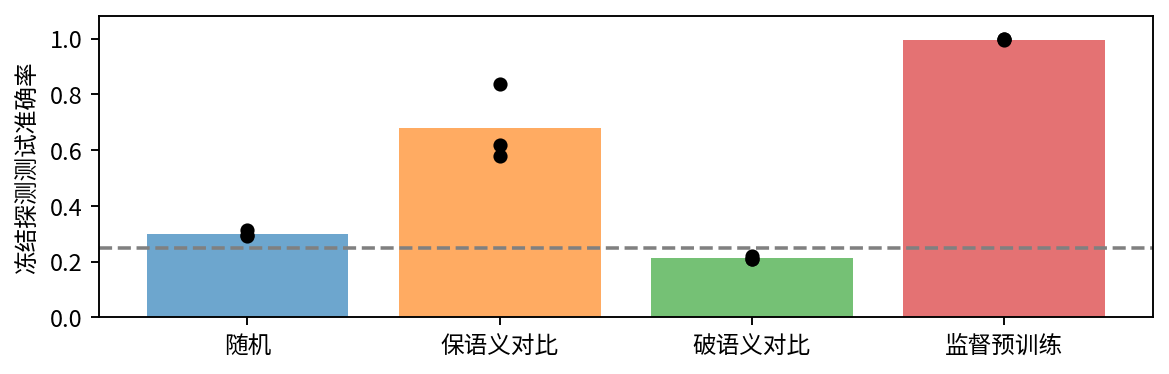

In [8]:
from IPython.display import display,Image
display(Image(filename=str(ROOT/"figures/03_probe.png")))


## 8 写下自己的解释
回答lecture末尾十题，先解释目标和评价是否一致，再比较均值。只有一个固定合成划分，不能外推真实场景。